# Stage 4 - Interpretable Baseline

~45 hand-engineered kinematic scalars into LightGBM, evaluated with 7-fold grouped LOVO, explained with SHAP.

### Why this comes before the neural model

Two reasons, and both matter more than the accuracy number:

1. **It establishes a floor.** If a gradient-boosted tree on 45 scalars beats the skeleton model in Stage 5, the problem is the pipeline, not model capacity - and you'd want to know that before spending days on architecture.
2. **SHAP tells you which kinematics actually carry the signal**, which tells you what Stage 5's encoder must preserve. Skipping this is how people end up tuning a model that was never going to work.

### Expected result

**62-70% macro-F1**, LOVO-averaged.

| class | expected F1 | why |
|---|---|---|
| serve | ~0.93 | long preparatory stillness makes it nearly separable on one feature |
| attack | ~0.78 | large amplitude, high peak wrist speed |
| defence | ~0.58 | heterogeneous - block is close, chop/lob are deep |
| control | ~0.55 | the hard pair with defence/block |

### Gate

**Serve F1 > 0.90.** Serve is close to linearly separable from stillness duration alone, so a low score means a pipeline bug rather than a modelling limit. Stop and investigate if it fails.

Runs in ~2 min. No GPU needed.


## 1. Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Setup

In [2]:
BASE = "/content/drive/MyDrive/tt_coach"

!pip install -q lightgbm shap 2>&1 | tail -1

import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

BASE    = Path(BASE)
META    = BASE / "derived/meta"
CLIPDIR = BASE / "derived/clips"
OUT     = BASE / "outputs"
(OUT / "metrics").mkdir(parents=True, exist_ok=True)
(OUT / "figures").mkdir(parents=True, exist_ok=True)

d = np.load(CLIPDIR / "canonical.npz", allow_pickle=True)
PRE, NF = int(d["contact_index"]), int(d["n_frames"])
FPS = 120

KP, VEL, VALID = d["kp"].astype(np.float32), d["vel"].astype(np.float32), d["valid"]
TDIST, PW = d["table_dist"].astype(np.float32), d["playing_wrist"]
usable = d["usable"]

meta = pd.DataFrame({
    "stroke_id": d["stroke_id"], "video_id": d["video_id"], "fold": d["fold"],
    "shot_class": d["shot_class"], "high_level": d["high_level"],
    "technique": d["technique"], "eff_hand": d["eff_hand"],
})

CLASSES = ["serve", "attack", "control", "defence"]   # fixed order everywhere
print(f"{len(meta)} strokes, {usable.sum()} usable")
print(f"window {NF} frames @ {FPS}fps, contact at index {PRE}")

1457 strokes, 1432 usable
window 97 frames @ 120fps, contact at index 60


## 3. Feature extraction

Five families, chosen to match the physical distinctions the taxonomy rests on.

| family | separates |
|---|---|
| **Preparation** | serve - a long still period before the swing |
| **Amplitude** | attack (big backswing) vs control/defence (compact) |
| **Velocity** | attack (high peak, fast acceleration) vs everything |
| **Configuration at contact** | wrist height, elbow angle, trunk lean |
| **Position** | defence - choppers retreat from the table |

Coordinates are hip-centred and torso-scaled, so every distance is in torso-lengths and every speed in torso-lengths per frame. `h = -y` so larger means higher.

In [3]:
NOSE = 0
L_SHO, R_SHO, L_ELB, R_ELB, L_WRI, R_WRI = 5, 6, 7, 8, 9, 10
L_HIP, R_HIP, L_KNE, R_KNE, L_ANK, R_ANK = 11, 12, 13, 14, 15, 16
ARM = {R_WRI: (R_SHO, R_ELB, R_WRI), L_WRI: (L_SHO, L_ELB, L_WRI)}


def angle(a, b, c):
    """Angle at b, in degrees, for point sequences (T,2)."""
    v1, v2 = a - b, c - b
    n1 = np.linalg.norm(v1, axis=-1); n2 = np.linalg.norm(v2, axis=-1)
    cos = np.sum(v1 * v2, axis=-1) / np.maximum(n1 * n2, 1e-6)
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))


def safe(x, fn=np.nanmax, default=np.nan):
    x = np.asarray(x, np.float32)
    x = x[np.isfinite(x)]
    return float(fn(x)) if x.size else default


def features(i):
    kp, vel, val = KP[i, 0], VEL[i, 0], VALID[i, 0]     # striker
    w   = int(PW[i])                                     # playing wrist index
    fw  = L_WRI if w == R_WRI else R_WRI                 # free wrist
    sho, elb, wri = ARM[w]

    h  = -kp[..., 1]                                     # height, up-positive
    spd = np.linalg.norm(vel, axis=-1)                   # (T, J)
    spd[~val] = np.nan
    wspd = spd[:, wri]
    pre, post = slice(0, PRE), slice(PRE, NF)

    f = {}

    # --- preparation ------------------------------------------------------
    pk = safe(wspd)
    if np.isfinite(pk) and pk > 0:
        moving = np.nan_to_num(wspd[pre]) > 0.15 * pk
        onset = int(np.argmax(moving)) if moving.any() else PRE
    else:
        onset = PRE
    f["prep_still_frames"] = onset
    f["prep_still_s"]      = onset / FPS
    f["prep_energy"]       = safe(wspd[pre], np.nansum)
    f["prep_mean_speed"]   = safe(wspd[pre], np.nanmean)
    f["prep_speed_ratio"]  = safe(wspd[pre], np.nanmean) / max(safe(wspd[post], np.nanmean), 1e-6)

    # --- amplitude --------------------------------------------------------
    f["amp_path_pre"]   = safe(wspd[pre], np.nansum)
    f["amp_path_post"]  = safe(wspd[post], np.nansum)
    f["amp_path_total"] = safe(wspd, np.nansum)
    d_hip = np.linalg.norm(kp[:, wri], axis=-1)          # hip is origin
    f["amp_max_reach"]  = safe(d_hip)
    f["amp_reach_range"] = safe(d_hip) - safe(d_hip, np.nanmin)
    f["amp_x_range"] = safe(kp[:, wri, 0]) - safe(kp[:, wri, 0], np.nanmin)
    f["amp_y_range"] = safe(h[:, wri])    - safe(h[:, wri], np.nanmin)
    f["amp_backswing"] = safe(d_hip[pre])                # furthest before contact
    f["amp_followthru"] = safe(d_hip[post])

    # --- velocity ---------------------------------------------------------
    f["vel_peak"]       = pk
    f["vel_peak_pre"]   = safe(wspd[pre])
    f["vel_peak_post"]  = safe(wspd[post])
    f["vel_at_contact"] = float(wspd[PRE]) if np.isfinite(wspd[PRE]) else np.nan
    f["vel_mean"]       = safe(wspd, np.nanmean)
    if np.isfinite(pk) and np.isfinite(wspd).any():
        f["vel_time_to_peak"] = int(np.nanargmax(wspd)) - PRE
    else:
        f["vel_time_to_peak"] = np.nan
    acc = np.diff(np.nan_to_num(wspd))
    f["vel_max_accel"] = safe(acc)
    f["vel_max_decel"] = safe(acc, np.nanmin)
    f["vel_free_peak"] = safe(spd[:, fw])
    f["vel_arm_ratio"] = pk / max(safe(spd[:, fw]), 1e-6)
    ea = angle(kp[:, sho], kp[:, elb], kp[:, wri])
    f["vel_elbow_ang_max"] = safe(np.abs(np.diff(ea)))
    f["vel_elbow_ang_mean"] = safe(np.abs(np.diff(ea)), np.nanmean)

    # --- configuration at contact ----------------------------------------
    c = PRE
    f["cfg_wrist_h_hip"]   = float(h[c, wri])
    f["cfg_wrist_h_sho"]   = float(h[c, wri] - (h[c, L_SHO] + h[c, R_SHO]) / 2)
    f["cfg_wrist_x"]       = float(kp[c, wri, 0])
    f["cfg_wrist_reach"]   = float(d_hip[c])
    f["cfg_elbow_angle"]   = float(ea[c])
    f["cfg_elbow_min"]     = safe(ea, np.nanmin)
    f["cfg_elbow_max"]     = safe(ea)
    f["cfg_shoulder_angle"] = float(
        angle(kp[c, elb][None], kp[c, sho][None],
              ((kp[c, L_HIP] + kp[c, R_HIP]) / 2)[None])[0])
    trunk = kp[:, L_SHO] / 2 + kp[:, R_SHO] / 2
    f["cfg_trunk_lean"] = float(np.degrees(np.arctan2(trunk[c, 0], -trunk[c, 1])))
    f["cfg_trunk_lean_rng"] = safe(np.degrees(np.arctan2(trunk[:, 0], -trunk[:, 1]))) - \
                              safe(np.degrees(np.arctan2(trunk[:, 0], -trunk[:, 1])), np.nanmin)
    f["cfg_sho_width"] = float(np.linalg.norm(kp[c, L_SHO] - kp[c, R_SHO]))
    f["cfg_knee_angle"] = float(
        (angle(kp[c, L_HIP][None], kp[c, L_KNE][None], kp[c, L_ANK][None])[0] +
         angle(kp[c, R_HIP][None], kp[c, R_KNE][None], kp[c, R_ANK][None])[0]) / 2)
    f["cfg_stance_width"] = float(abs(kp[c, L_ANK, 0] - kp[c, R_ANK, 0]))
    f["cfg_hip_h"] = float(h[c, L_HIP] / 2 + h[c, R_HIP] / 2)

    # --- position ---------------------------------------------------------
    td = TDIST[i]
    f["pos_table_dist"]      = float(td[c]) if np.isfinite(td[c]) else np.nan
    f["pos_table_dist_mean"] = safe(td, np.nanmean)
    f["pos_table_dist_min"]  = safe(td, np.nanmin)
    f["pos_table_approach"]  = safe(td[post], np.nanmean) - safe(td[pre], np.nanmean)
    f["pos_body_drift"]      = safe(np.abs(np.diff(np.nan_to_num(kp[:, L_HIP, 0]))), np.nansum)

    # --- context ----------------------------------------------------------
    f["ctx_eff_hand_R"] = 1.0 if meta.eff_hand.iloc[i] == "R" else 0.0
    f["ctx_valid_pct"]  = float(val.mean())
    return f


rows = [features(i) for i in range(len(meta))]
X = pd.DataFrame(rows).astype(np.float32)
FEATS = list(X.columns)
print(f"{len(FEATS)} features")
print(f"NaN rate: {X.isna().mean().mean():.4f}")
worst = X.isna().mean().sort_values(ascending=False).head(5)
print(f"most-missing:\n{worst.to_string()}")

47 features
NaN rate: 0.0058
most-missing:
vel_at_contact      0.015786
prep_speed_ratio    0.015100
prep_energy         0.015100
amp_path_pre        0.015100
amp_path_post       0.015100


## 4. LOVO cross-validation

Split by fold, never by stroke. The v1 experiment reached 81.8% validation accuracy on epoch 1 with a shuffled split - pure memorisation of strokes from the same rally landing on both sides. Any number from a random split is meaningless here.

Class weights are balanced to stop the 2.9:1 imbalance from burying `defence`.

In [4]:
import lightgbm as lgb
from sklearn.metrics import f1_score, classification_report, confusion_matrix

m = meta[usable].reset_index(drop=True)
Xu = X[usable].reset_index(drop=True)
y = m.shot_class.map({c: i for i, c in enumerate(CLASSES)}).values
FOLDS = sorted(m.fold.unique())

PARAMS = dict(objective="multiclass", num_class=4, learning_rate=0.05,
              num_leaves=15, min_child_samples=20, feature_fraction=0.7,
              bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
              n_estimators=400, verbose=-1, n_jobs=-1)

oof = np.zeros((len(Xu), 4))
per_fold, models = [], {}

for f in FOLDS:
    tr, va = m.fold != f, m.fold == f
    cw = len(y[tr]) / (4 * np.bincount(y[tr], minlength=4).clip(1))
    clf = lgb.LGBMClassifier(**PARAMS,
                             class_weight={i: cw[i] for i in range(4)})
    clf.fit(Xu[tr], y[tr])
    p = clf.predict_proba(Xu[va])
    oof[va.values] = p
    models[f] = clf

    yt, yp = y[va.values], p.argmax(1)
    row = {"fold": f, "n": int(va.sum()),
           "macro_f1": f1_score(yt, yp, average="macro", zero_division=0),
           "acc": (yt == yp).mean()}
    for ci, c in enumerate(CLASSES):
        row[c] = f1_score(yt == ci, yp == ci, zero_division=0)
        row[f"n_{c}"] = int((yt == ci).sum())
    per_fold.append(row)

pf = pd.DataFrame(per_fold)
pf.to_csv(OUT / "metrics/stage4_folds.csv", index=False)
print(pf[["fold", "n", "macro_f1", "acc"] + CLASSES].to_string(
    index=False, float_format=lambda x: f"{x:.3f}"))

w = pf.n / pf.n.sum()
print(f"\n  support-weighted macro-F1 : {(pf.macro_f1 * w).sum():.3f}")
print(f"  unweighted mean           : {pf.macro_f1.mean():.3f} "
      f"+/- {pf.macro_f1.std():.3f}")

fold   n  macro_f1   acc  serve  attack  control  defence
   A 160     0.636 0.669  0.844   0.779    0.649    0.273
   B 385     0.782 0.831  0.949   0.852    0.816    0.512
   C 152     0.695 0.730  0.820   0.818    0.653    0.491
   D 170     0.497 0.529  0.766   0.618    0.493    0.109
   E 248     0.609 0.685  0.887   0.644    0.793    0.113
   F 155     0.799 0.800  0.951   0.818    0.875    0.552
   G 162     0.729 0.759  0.906   0.805    0.667    0.538

  support-weighted macro-F1 : 0.689
  unweighted mean           : 0.678 +/- 0.106


## 5. Overall result & gate

In [5]:
yp = oof.argmax(1)
print(classification_report(y, yp, target_names=CLASSES,
                            digits=3, zero_division=0))

cm = confusion_matrix(y, yp)
cmdf = pd.DataFrame(cm, index=[f"true_{c}" for c in CLASSES],
                    columns=[f"pred_{c}" for c in CLASSES])
cmdf["recall"] = (np.diag(cm) / cm.sum(1)).round(3)
print("CONFUSION MATRIX")
print(cmdf.to_string())
cmdf.to_csv(OUT / "metrics/stage4_confusion.csv")

overall = f1_score(y, yp, average="macro", zero_division=0)
serve_f1 = f1_score(y == 0, yp == 0, zero_division=0)

print("\n" + "=" * 66)
print(f"  OOF macro-F1 : {overall:.3f}   (expected 0.62 - 0.70)")
print(f"  serve F1     : {serve_f1:.3f}   gate > 0.90 -> "
      f"{'PASS' if serve_f1 > 0.90 else 'FAIL'}")
if serve_f1 <= 0.90:
    print("\n  !! Serve is nearly separable on preparatory stillness alone.")
    print("     A low score points to a pipeline bug (contact-frame")
    print("     misalignment, wrong striker, bad canonicalisation) rather")
    print("     than a modelling limit. Investigate before Stage 5.")

# the pair we expect to be hard
cc = cm[2, 3] + cm[3, 2]
print(f"\n  control <-> defence confusion: {cc} of {cm[2].sum()+cm[3].sum()} "
      f"({100*cc/(cm[2].sum()+cm[3].sum()):.1f}%)")
print("=" * 66)

              precision    recall  f1-score   support

       serve      0.920     0.870     0.894       277
      attack      0.746     0.803     0.773       650
     control      0.740     0.724     0.732       279
     defence      0.406     0.354     0.378       226

    accuracy                          0.730      1432
   macro avg      0.703     0.688     0.694      1432
weighted avg      0.725     0.730     0.726      1432

CONFUSION MATRIX
              pred_serve  pred_attack  pred_control  pred_defence  recall
true_serve           241           24             1            11   0.870
true_attack           11          522            43            74   0.803
true_control           2           43           202            32   0.724
true_defence           8          111            27            80   0.354

  OOF macro-F1 : 0.694   (expected 0.62 - 0.70)
  serve F1     : 0.894   gate > 0.90 -> FAIL

  !! Serve is nearly separable on preparatory stillness alone.
     A low score poi

## 6. SHAP - what actually carries the signal

This is the output that shapes Stage 5. If a family of features contributes nothing, the encoder does not need to preserve it; if one dominates, the encoder must.

TOP 15 FEATURES
                     serve  attack  control  defence  overall
cfg_wrist_x         1.0462  0.0853   0.5160   0.0513   0.4247
cfg_elbow_min       0.9079  0.4823   0.1482   0.0952   0.4084
amp_followthru      0.4921  0.3674   0.2645   0.3413   0.3663
amp_y_range         0.0277  0.6619   0.6811   0.0864   0.3643
cfg_shoulder_angle  0.5826  0.3889   0.0674   0.1419   0.2952
cfg_stance_width    0.5700  0.1293   0.1481   0.2094   0.2642
cfg_knee_angle      0.4894  0.0857   0.0900   0.2339   0.2247
amp_x_range         0.1300  0.1903   0.2771   0.2950   0.2231
cfg_elbow_angle     0.1129  0.4824   0.1012   0.1891   0.2214
vel_peak_post       0.0250  0.5510   0.2483   0.0593   0.2209
cfg_sho_width       0.0362  0.4362   0.2637   0.0845   0.2051
pos_table_dist_mean 0.0848  0.1657   0.1572   0.3373   0.1862
pos_body_drift      0.3594  0.0427   0.2547   0.0737   0.1826
vel_elbow_ang_mean  0.1645  0.0635   0.0644   0.3775   0.1675
pos_table_dist_min  0.1037  0.0560   0.0960   0.3953  

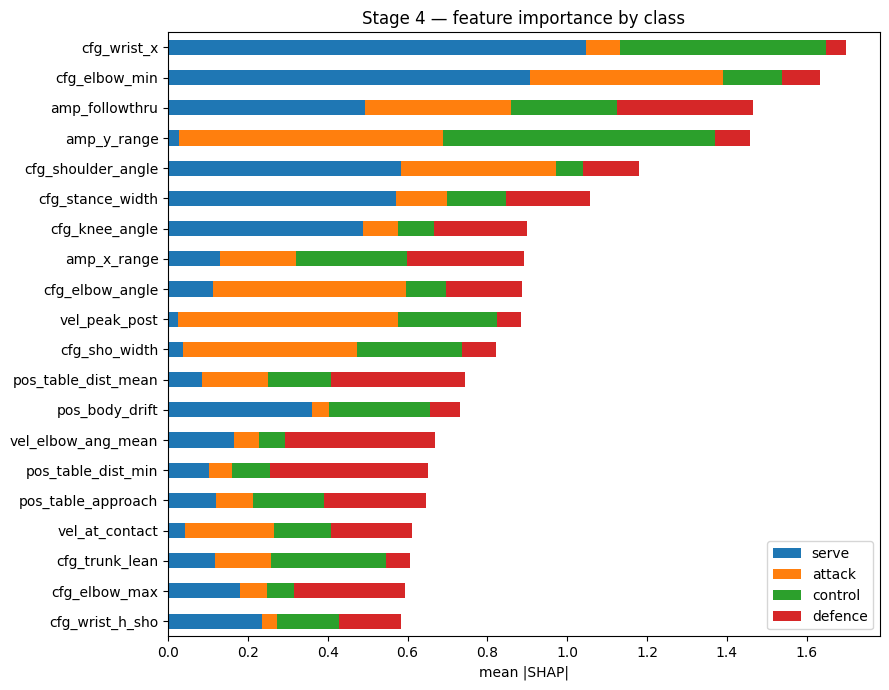

In [6]:
import shap
import matplotlib.pyplot as plt

expl = shap.TreeExplainer(models[FOLDS[1]])
sv = expl.shap_values(Xu)
sv = np.stack(sv, -1) if isinstance(sv, list) else sv     # (n, feat, class)

imp = pd.DataFrame(
    {c: np.abs(sv[..., i]).mean(0) for i, c in enumerate(CLASSES)},
    index=FEATS)
imp["overall"] = imp.mean(1)
imp = imp.sort_values("overall", ascending=False)
imp.to_csv(OUT / "metrics/stage4_shap.csv")

print("TOP 15 FEATURES")
print(imp.head(15).to_string(float_format=lambda x: f"{x:.4f}"))

print("\nTOP 3 PER CLASS")
for c in CLASSES:
    print(f"  {c:<8} {list(imp[c].sort_values(ascending=False).head(3).index)}")

fam = imp.copy()
fam["family"] = [f.split("_")[0] for f in fam.index]
print("\nBY FAMILY (mean |SHAP|)")
print(fam.groupby("family").overall.agg(["mean", "sum", "size"])
        .sort_values("sum", ascending=False)
        .to_string(float_format=lambda x: f"{x:.4f}"))

fig, ax = plt.subplots(figsize=(9, 7))
imp.head(20)[CLASSES].plot.barh(stacked=True, ax=ax)
ax.invert_yaxis(); ax.set_xlabel("mean |SHAP|")
ax.set_title("Stage 4 - feature importance by class")
plt.tight_layout()
plt.savefig(OUT / "figures/stage4_shap.png", dpi=130)
plt.show()

## 7. Error analysis

In [7]:
m2 = m.copy()
m2["pred"] = [CLASSES[i] for i in yp]
m2["conf"] = oof.max(1)
m2["correct"] = m2.pred == m2.shot_class

print("accuracy by original technique (where the 4-class grouping strains)")
print(m2.groupby("technique")
        .agg(n=("correct", "size"), acc=("correct", "mean"))
        .sort_values("n", ascending=False)
        .to_string(float_format=lambda x: f"{x:.3f}"))

print("\naccuracy by forehand/backhand")
print(m2.groupby("high_level").correct.agg(["size", "mean"])
        .to_string(float_format=lambda x: f"{x:.3f}"))

print("\naccuracy by effective handedness")
print(m2.groupby("eff_hand").correct.agg(["size", "mean"])
        .to_string(float_format=lambda x: f"{x:.3f}"))

thr = np.quantile(m2.conf, 0.10)
keep = m2.conf >= thr
print(f"\nabstaining on the least-confident 10% (conf < {thr:.3f}):")
print(f"  accuracy {m2.correct.mean():.3f} -> {m2[keep].correct.mean():.3f}")
print("  For a coaching tool, an explicit 'uncertain' beats a confident error.")

m2.to_csv(OUT / "metrics/stage4_predictions.csv", index=False)
print(f"\n-> {OUT/'metrics'}")

accuracy by original technique (where the 4-class grouping strains)
             n   acc
technique           
loop       574 0.821
push       279 0.724
serve      277 0.870
block      186 0.419
flick       64 0.641
chop        31 0.065
smash       12 0.833
lob          9 0.000

accuracy by forehand/backhand
            size  mean
high_level            
backhand     765 0.669
forehand     667 0.799

accuracy by effective handedness
          size  mean
eff_hand            
L          681 0.711
R          751 0.747

abstaining on the least-confident 10% (conf < 0.610):
  accuracy 0.730 -> 0.766
  For a coaching tool, an explicit 'uncertain' beats a confident error.

-> /content/drive/MyDrive/tt_coach/outputs/metrics


---
## Done

| artifact | purpose |
|---|---|
| `outputs/metrics/stage4_folds.csv` | per-fold, per-class F1 |
| `outputs/metrics/stage4_confusion.csv` | confusion matrix |
| `outputs/metrics/stage4_shap.csv` | feature importance |
| `outputs/metrics/stage4_predictions.csv` | per-stroke predictions for error analysis |
| `outputs/figures/stage4_shap.png` | importance plot |

**Read the result in this order:**

1. **Serve F1 > 0.90?** If not, stop - it's a pipeline bug, not a model limit.
2. **Macro-F1 in 0.62-0.70?** That's the expected floor. Much lower means something upstream is wrong; much higher means the problem is easier than assumed and Stage 5's target should rise.
3. **Where is control<->defence confusion?** This is the predicted hard pair. If it dominates the matrix, consider splitting `defence` into `defence_close` (block) and `defence_deep` (chop/lob) - a one-line change in `TAXONOMY.yaml`.
4. **Which feature families matter?** Stage 5's encoder must preserve whatever SHAP ranks highest.
5. **Fold spread.** High variance means the folds are measuring different things; check whether fold E (6 defence) or fold G is the outlier.

Next: **`05_skeleton_model.ipynb`** - multi-task PoseC3D/CTR-GCN with lean and feet auxiliary heads, target 72-80% macro-F1.


In [8]:
# =============================================================================
# CELL 8 - TAXONOMY COMPARISON
#
# The by-technique breakdown showed `defence` (block 0.42 / chop 0.07 / lob 0.00)
# has no coherent kinematic signature: it is 82% block, so the model learns
# "defence == block-shaped" and the deep strokes get pushed into attack.
#
# Rather than argue about the right regrouping, run LOVO on each candidate and
# read the numbers. Reuses X / meta / usable from the cells above - no
# recomputation, ~1 min total.
# =============================================================================

import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import f1_score, confusion_matrix

# --- fix the three dead/duplicate features found via SHAP --------------------
#   cfg_hip_h        identically 0 (hip IS the origin after hip-centring)
#   prep_energy      same expression as amp_path_pre
#   prep_still_s     prep_still_frames / 120
DROP = [c for c in ["cfg_hip_h", "prep_energy", "prep_still_s"] if c in X.columns]
Xc = X.drop(columns=DROP)
print(f"dropped dead/duplicate features: {DROP}  ->  {Xc.shape[1]} remain\n")

TAXONOMIES = {
    "v1_current": {
        "serve":   ["serve"],
        "attack":  ["loop", "smash", "flick"],
        "control": ["push"],
        "defence": ["block", "chop", "lob"],
    },
    # block is passive and close to the table, like push. Deep defence stands alone.
    "v2_block_to_control": {
        "serve":   ["serve"],
        "attack":  ["loop", "smash", "flick"],
        "control": ["push", "block"],
        "defence": ["chop", "lob"],
    },
    # split rather than move: keeps push distinct, isolates deep defence
    "v3_split_defence": {
        "serve":         ["serve"],
        "attack":        ["loop", "smash", "flick"],
        "control":       ["push"],
        "defence_close": ["block"],
        "defence_deep":  ["chop", "lob"],
    },
    # coarse: one passive class, guaranteed support in every fold
    "v4_three_class": {
        "serve":     ["serve"],
        "attack":    ["loop", "smash", "flick"],
        "defensive": ["push", "block", "chop", "lob"],
    },
}

mu, Xu2 = meta[usable].reset_index(drop=True), Xc[usable].reset_index(drop=True)
FOLDS = sorted(mu.fold.unique())
BASE_PARAMS = dict(objective="multiclass", learning_rate=0.05, num_leaves=15,
                   min_child_samples=20, feature_fraction=0.7,
                   bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                   n_estimators=400, verbose=-1, n_jobs=-1)


def evaluate(name, tax):
    classes = list(tax)
    t2c = {t: c for c, ts in tax.items() for t in ts}
    lab = mu.technique.map(t2c)
    keep = lab.notna().values
    y = lab[keep].map({c: i for i, c in enumerate(classes)}).values.astype(int)
    Xk = Xu2[keep].reset_index(drop=True)
    fold = mu.fold[keep].values

    # fold coverage: a class with zero support in a fold cannot be scored there
    cov = pd.crosstab(fold, [classes[i] for i in y])
    cov = cov.reindex(columns=classes, fill_value=0)
    empty = int((cov == 0).sum().sum())

    oof = np.zeros((len(y), len(classes)))
    for f in FOLDS:
        tr, va = fold != f, fold == f
        if not va.any():
            continue
        cnt = np.bincount(y[tr], minlength=len(classes)).clip(1)
        cw = len(y[tr]) / (len(classes) * cnt)
        clf = lgb.LGBMClassifier(**BASE_PARAMS, num_class=len(classes),
                                 class_weight={i: cw[i] for i in range(len(classes))})
        clf.fit(Xk[tr], y[tr])
        oof[va] = clf.predict_proba(Xk[va])

    yp = oof.argmax(1)
    per = {c: f1_score(y == i, yp == i, zero_division=0) for i, c in enumerate(classes)}
    return {
        "taxonomy": name, "n_classes": len(classes), "n": len(y),
        "macro_f1": f1_score(y, yp, average="macro", zero_division=0),
        "accuracy": float((y == yp).mean()),
        "min_class_f1": min(per.values()),
        "empty_fold_cells": empty,
        "min_support": int(cov.values.min()),
        **{f"F1_{c}": v for c, v in per.items()},
    }, cov, (y, yp, classes)


results, details = [], {}
for name, tax in TAXONOMIES.items():
    r, cov, dat = evaluate(name, tax)
    results.append(r); details[name] = (cov, dat)
    print(f"  {name:<22} macro-F1 {r['macro_f1']:.3f}   "
          f"acc {r['accuracy']:.3f}   weakest class {r['min_class_f1']:.3f}   "
          f"empty fold-cells {r['empty_fold_cells']}")

res = pd.DataFrame(results)
res.to_csv(OUT / "metrics/stage4_taxonomy_comparison.csv", index=False)

print("\n" + "=" * 78)
print("COMPARISON")
print("=" * 78)
cols = ["taxonomy", "n_classes", "macro_f1", "accuracy", "min_class_f1",
        "empty_fold_cells", "min_support"]
print(res[cols].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\nPER-CLASS F1")
f1cols = [c for c in res.columns if c.startswith("F1_")]
print(res.set_index("taxonomy")[f1cols].to_string(float_format=lambda x: f"{x:.3f}"))

print("\n" + "=" * 78)
print("FOLD COVERAGE  (zero = that fold cannot score that class)")
print("=" * 78)
for name in TAXONOMIES:
    cov = details[name][0]
    bad = (cov == 0).sum().sum()
    print(f"\n{name}   {'OK' if bad == 0 else f'!! {bad} empty cells'}")
    print(cov.to_string())

print("\n" + "=" * 78)
print("CONFUSION - best scheme")
print("=" * 78)
best = res.sort_values("macro_f1", ascending=False).iloc[0]
y, yp, classes = details[best.taxonomy][1]
cm = confusion_matrix(y, yp)
cmdf = pd.DataFrame(cm, index=[f"true_{c}" for c in classes],
                    columns=[f"pred_{c}" for c in classes])
cmdf["recall"] = (np.diag(cm) / cm.sum(1)).round(3)
print(f"{best.taxonomy}  (macro-F1 {best.macro_f1:.3f})")
print(cmdf.to_string())

print("\n" + "=" * 78)
print("HOW TO CHOOSE")
print("=" * 78)
print("""  Macro-F1 alone is misleading here: fewer classes is mechanically easier,
  so v4 (3-class) has an advantage that is not a real improvement.

  Weigh three things together:
    1. min_class_f1    - does every class actually work, or is one carried?
    2. empty_fold_cells - any zero means that fold cannot score that class,
                          so its macro-F1 is computed over fewer classes and
                          is not comparable to the others.
    3. product value   - separating passive play from deep defence is worth
                          real accuracy; a class nobody can predict is not.

  Then set TAXONOMY.yaml to the winner and re-run notebook 00 and this one.
  If the fine distinctions still matter but cannot be primary classes, keep
  the coarse scheme here and add `technique` as an auxiliary head in Stage 5 -
  the encoder still learns them without their needing to be evaluable.""")
print("=" * 78)

dropped dead/duplicate features: ['cfg_hip_h', 'prep_energy', 'prep_still_s']  ->  44 remain

  v1_current             macro-F1 0.693   acc 0.730   weakest class 0.367   empty fold-cells 0
  v2_block_to_control    macro-F1 0.615   acc 0.767   weakest class 0.070   empty fold-cells 1
  v3_split_defence       macro-F1 0.586   acc 0.736   weakest class 0.098   empty fold-cells 1
  v4_three_class         macro-F1 0.789   acc 0.772   weakest class 0.705   empty fold-cells 0

COMPARISON
           taxonomy  n_classes  macro_f1  accuracy  min_class_f1  empty_fold_cells  min_support
         v1_current          4     0.693     0.730         0.367                 0            6
v2_block_to_control          4     0.615     0.767         0.070                 1            0
   v3_split_defence          5     0.586     0.736         0.098                 1            0
     v4_three_class          3     0.789     0.772         0.705                 0           24

PER-CLASS F1
                    